# 260414-2: PyTorch로 CNN Classifier 구현하기

260414-1에서 직접 구현한 convolution과 pooling을 이제 PyTorch module로 조립합니다.  
`nn.Conv2d`, `nn.MaxPool2d`, `nn.Sequential`을 사용해 CIFAR-10 classifier를 만들고, MLP와 CNN의 차이를 비교합니다.

## 학습 목표
- `nn.Conv2d`와 `nn.MaxPool2d`의 입력/출력 shape을 추적한다.
- `Conv -> ReLU -> Pool -> FC` 구조의 작은 CNN을 구현한다.
- CIFAR-10 DataLoader와 학습 loop를 구성한다.
- MLP와 CNN의 parameter 수 및 성능 차이를 비교한다.
- 첫 convolution filter와 activation map을 시각화한다.

## 구성
| 순서 | 내용 | 핵심 질문 |
|---|---|---|
| 1 | CIFAR-10 DataLoader | 이미지 tensor는 어떤 shape으로 모델에 들어가는가? |
| 2 | Conv/Pool shape check | 각 layer는 channel과 spatial size를 어떻게 바꾸는가? |
| 3 | SimpleCNN 구현 | 강의의 CNN building block은 PyTorch에서 어떻게 표현되는가? |
| 4 | CNN 학습 | loss와 accuracy를 어떻게 해석하는가? |
| 5 | MLP vs CNN | 이미지 문제에서 CNN의 inductive bias는 어떤 장점이 있는가? |
| 6 | Filter/feature map 시각화 | CNN이 학습한 local pattern을 어떻게 볼 수 있는가? |

## 이론 설명

### 핵심 개념 정리
PyTorch에서는 CNN의 각 구성요소가 `nn.Module`로 제공됩니다. 직접 loop를 돌려 convolution을 계산하지 않고, module을 쌓아 forward graph를 정의하면 autograd가 gradient를 자동 계산합니다.

| 강의 표현 | PyTorch module | 역할 |
|---|---|---|
| Convolutional layer | `nn.Conv2d` | local feature 추출, channel 변환 |
| ReLU layer | `nn.ReLU` | 비선형성 추가 |
| Pooling layer | `nn.MaxPool2d` | spatial down-sampling |
| Fully connected layer | `nn.Linear` | class score 계산 |
| Full CNN architecture | `nn.Sequential`, `nn.Module` | layer 조립과 forward 정의 |

이번 실습에서는 shape을 계속 추적하는 것이 중요합니다. CIFAR-10 입력은 `(N, 3, 32, 32)`이고, 두 번의 2x2 pooling을 지나면 spatial 크기가 `32 -> 16 -> 8`로 줄어듭니다.

### Shape 읽는 법

PyTorch image tensor는 `(N, C, H, W)` 순서입니다. 이 순서를 계속 머릿속에 두고 layer를 읽어야 합니다.

- `N`: batch size
- `C`: channel 수, CIFAR-10 RGB 이미지는 3
- `H, W`: height와 width

또한, `Conv2d(3, 32, kernel_size=3, padding=1)`은 channel을 3에서 32로 바꾸고, spatial 크기 32x32는 유지합니다.
`MaxPool2d(2)`는 channel 수는 유지하고 spatial 크기만 절반으로 줄입니다.

## 코드 실습

이제 CIFAR-10 데이터를 불러오고 PyTorch CNN을 구현합니다. 실습은 day2의 PyTorch 학습 흐름과 같은 구조를 따릅니다.

`model -> loss -> backward -> optimizer.step()` 패턴은 그대로이고, 달라지는 부분은 MLP 대신 `Conv2d`, `MaxPool2d`가 들어간다는 점입니다.

### 실행 안내

아래 import 셀에서는 day2에서 사용한 PyTorch 학습 도구에 `torchvision`을 더해 CIFAR-10 데이터를 불러옵니다.

- `torchvision.transforms`는 이미지 전처리를 담당합니다.
- `DataLoader`는 mini-batch를 만들어 학습 loop에 공급합니다.
- `device`는 GPU가 있으면 `cuda`, 없으면 `cpu`로 설정됩니다.

이후 모든 model과 tensor는 같은 device에 있어야 합니다. model은 GPU에 있는데 input이 CPU에 있으면 PyTorch가 오류를 냅니다.

In [1]:
# Colab / local environment check
import sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    import subprocess
    gpu_info = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
    if gpu_info.returncode == 0:
        print('GPU available')
        print(gpu_info.stdout.split('\n')[0])
    else:
        print('GPU is not available. Runtime > Change runtime type > GPU 를 선택하세요.')
else:
    print('Running outside Colab')


GPU available
Tue Apr 14 05:47:40 2026       


In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset, random_split

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)


device: cuda


## 1. CIFAR-10 DataLoader

실습 시간을 고려하여 기본값은 작은 epoch으로 둡니다. 더 높은 성능을 보고 싶으면 `FAST_DEV_RUN=False`로 바꾸고 epoch 수를 늘리세요.

### 데이터 안내

CIFAR-10은 32x32 컬러 이미지 10개 class로 구성된 작은 vision benchmark입니다. 각 이미지는 PyTorch에서 `(C, H, W) = (3, 32, 32)` tensor로 표현됩니다.

전처리 순서는 다음과 같습니다.

1. `ToTensor()`가 PIL 이미지를 `[0, 1]` 범위의 tensor로 바꿉니다.
2. `Normalize(mean, std)`가 channel별 평균과 표준편차로 정규화합니다.
3. subset을 만들어 수업 중 실행 시간을 줄입니다.

정규화된 이미지는 그대로 `imshow`하면 색이 이상해 보일 수 있으므로, 시각화할 때는 아래 `denormalize` 함수를 사용합니다.

In [3]:
FAST_DEV_RUN = True
BATCH_SIZE = 128
NUM_WORKERS = 2

transform_train = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

data_root = './data'
train_full = torchvision.datasets.CIFAR10(root=data_root, train=True, download=True, transform=transform_train)
test_set = torchvision.datasets.CIFAR10(root=data_root, train=False, download=True, transform=transform_test)
classes = train_full.classes

train_size = 5000 if FAST_DEV_RUN else 45000
val_size = 1000 if FAST_DEV_RUN else 5000
test_size = 1000 if FAST_DEV_RUN else len(test_set)

train_subset = Subset(train_full, list(range(train_size)))
val_subset = Subset(train_full, list(range(train_size, train_size + val_size)))
test_subset = Subset(test_set, list(range(test_size)))

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f'train/val/test: {len(train_subset)}, {len(val_subset)}, {len(test_subset)}')
print('classes:', classes)


100%|██████████| 170M/170M [00:04<00:00, 40.1MB/s]


train/val/test: 5000, 1000, 1000
classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


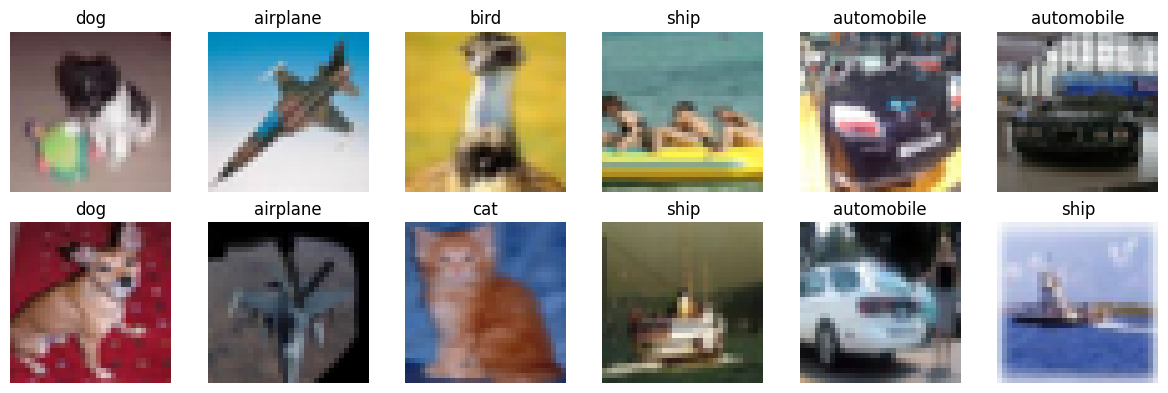

In [4]:
def denormalize(img):
    mean = torch.tensor((0.4914, 0.4822, 0.4465)).view(3, 1, 1)
    std = torch.tensor((0.2470, 0.2435, 0.2616)).view(3, 1, 1)
    return torch.clamp(img.cpu() * std + mean, 0, 1)

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for ax, img, label in zip(axes.ravel(), images[:12], labels[:12]):
    ax.imshow(denormalize(img).permute(1, 2, 0))
    ax.set_title(classes[label])
    ax.axis('off')
plt.tight_layout()
plt.show()


### 관찰 포인트

이미지와 label을 눈으로 확인하는 것은 사소해 보이지만 매우 중요합니다. 데이터가 정상적으로 로드되었는지, class 이름이 예상과 맞는지, normalization을 되돌린 이미지가 자연스럽게 보이는지 확인합니다.

실무에서도 학습 전 첫 mini-batch를 시각화하면 데이터 경로, label 매핑, transform 오류를 빨리 발견할 수 있습니다.

## 2. Shape Check: Conv2d and Pooling

`Conv2d(3, 32, kernel_size=3, padding=1)`은 32x32 spatial 크기를 유지하고 channel 수만 3에서 32로 바꿉니다.  
`MaxPool2d(2)`는 spatial 크기를 절반으로 줄입니다.

### Shape 읽는 법

CNN에서는 shape을 계속 추적하는 습관이 중요합니다. PyTorch image tensor는 `(N, C, H, W)` 순서입니다.

아래 예시는 다음 흐름을 보여줍니다.

- 입력: `(4, 3, 32, 32)`
- 첫 Conv: channel 3에서 32로 증가, padding 1이라 spatial은 32 유지
- 첫 Pool: spatial 32에서 16으로 감소
- 두 번째 Conv: channel 32에서 64로 증가
- 두 번째 Pool: spatial 16에서 8로 감소

따라서 classifier에 들어가기 전 feature tensor는 `(N, 64, 8, 8)`입니다.

In [5]:
x = torch.randn(4, 3, 32, 32)
demo = nn.Sequential(
    nn.Conv2d(3, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2), #4, 32, 16, 16
    nn.Conv2d(32, 64, kernel_size=3, padding=1), #4, 64, 16, 16
    nn.ReLU(),
    nn.MaxPool2d(2),
)

with torch.no_grad():
    h = x
    for layer in demo:
        h = layer(h)
        print(f'{layer.__class__.__name__:>10}: {tuple(h.shape)}')


    Conv2d: (4, 32, 32, 32)
      ReLU: (4, 32, 32, 32)
 MaxPool2d: (4, 32, 16, 16)
    Conv2d: (4, 64, 16, 16)
      ReLU: (4, 64, 16, 16)
 MaxPool2d: (4, 64, 8, 8)


## 3. SimpleCNN 구현

강의의 `Conv -> ReLU -> Pool -> FC` 구조를 CIFAR-10에 맞게 구현합니다.

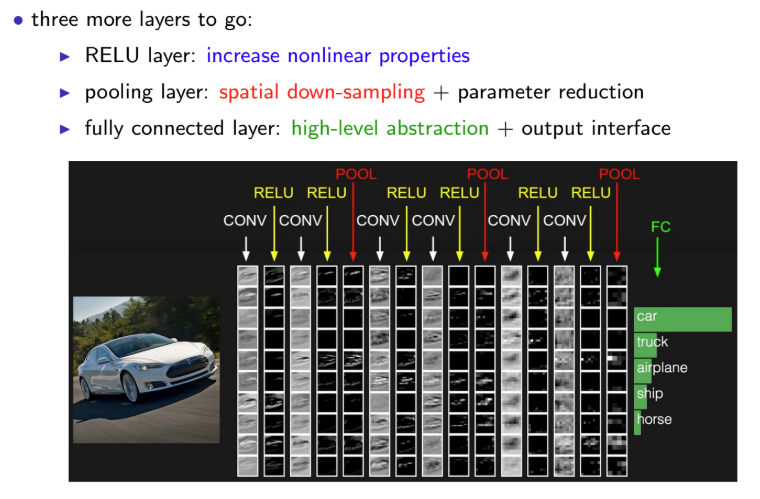

### 구현 안내

`SimpleCNN`은 강의의 `Conv -> ReLU -> Pool -> Fully Connected` 구조를 가장 작은 형태로 구현합니다.

구현을 나눠 생각하면 쉽습니다.

1. `self.features`: 이미지의 spatial feature를 추출합니다. 여기서는 Conv-ReLU-Pool block을 두 번 사용합니다.
2. `self.classifier`: feature map을 flatten한 뒤 class score 10개를 출력합니다.
3. `forward`: 입력을 feature extractor에 넣고, 그 결과를 classifier에 넣습니다.

첫 번째 pooling 후 spatial 크기는 16x16, 두 번째 pooling 후 8x8입니다. 그래서 `Linear`의 입력 차원은 `64 * 8 * 8`입니다.

In [12]:
class SimpleCNN(nn.Module):
    """Conv -> ReLU -> Pool 블록을 두 번 사용한 작은 CIFAR-10 CNN."""
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 128), #(4, 128)
            nn.ReLU(),
            nn.Linear(128, num_classes), #(4,)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


### 검증 안내

모델을 구현한 뒤에는 실제 학습 전에 dummy input으로 shape을 확인합니다. batch size 4의 이미지가 들어갔으므로 출력은 `(4, 10)`이어야 합니다.

여기서 10은 CIFAR-10 class 개수입니다. 출력값은 softmax 확률이 아니라 raw score(logit)입니다. `CrossEntropyLoss`가 내부에서 softmax와 negative log likelihood를 함께 처리합니다.

In [13]:
# SimpleCNN verification
model = SimpleCNN().to(device)
dummy = torch.randn(4, 3, 32, 32).to(device)
out = model(dummy)
print('output shape:', tuple(out.shape))
assert tuple(out.shape) == (4, 10)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Trainable parameters: {count_params(model):,}')


output shape: (4, 10)
Trainable parameters: 356,810


## 4. Training Utilities

### 코드 읽기

학습 utility는 day2와 같은 기본 구조입니다. 반복해서 등장하는 패턴이므로 익숙해지는 것이 좋습니다.

- `model.train()`: Dropout/BatchNorm 같은 layer를 학습 모드로 둡니다.
- `optimizer.zero_grad()`: 이전 mini-batch의 gradient를 지웁니다.
- `loss.backward()`: autograd로 gradient를 계산합니다.
- `optimizer.step()`: parameter를 업데이트합니다.
- `model.eval()`과 `torch.no_grad()`: 평가할 때 불필요한 gradient 계산을 끕니다.

BatchNorm/Dropout은 다음 노트북에서 다루도록 하겠습니다.

In [14]:
def check_accuracy(loader, model):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            scores = model(x)
            pred = scores.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.numel()
    return 100.0 * correct / total

def train_model(model, train_loader, val_loader, epochs=2, lr=1e-3, weight_decay=0.0):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()
    history = {'train_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            scores = model(x)
            loss = criterion(scores, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * y.size(0)
            correct += (scores.argmax(dim=1) == y).sum().item()
            total += y.numel()

        train_loss = total_loss / total
        train_acc = 100.0 * correct / total
        val_acc = check_accuracy(val_loader, model)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        print(f'Epoch {epoch:02d}: loss={train_loss:.4f}, train_acc={train_acc:.2f}%, val_acc={val_acc:.2f}%')
    return history

def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history['train_loss'], marker='o')
    axes[0].set_title(f'{title} loss')
    axes[0].set_xlabel('epoch')
    axes[0].set_ylabel('loss')
    axes[1].plot(history['train_acc'], marker='o', label='train')
    axes[1].plot(history['val_acc'], marker='o', label='val')
    axes[1].set_title(f'{title} accuracy')
    axes[1].set_xlabel('epoch')
    axes[1].set_ylabel('accuracy (%)')
    axes[1].legend()
    plt.show()


## 5. Train SimpleCNN

### 학습 출력 읽는 법

학습 셀을 실행하면 epoch마다 `loss`, `train_acc`, `val_acc`가 출력됩니다. 세 값은 서로 다른 질문에 답합니다.

- `loss`: optimizer가 직접 줄이려고 하는 값입니다. 대체로 내려가는 추세면 학습이 진행되고 있습니다.
- `train_acc`: 모델이 학습 데이터에 얼마나 잘 맞는지 봅니다. 너무 높고 validation이 낮으면 overfitting을 의심합니다.
- `val_acc`: 처음 보는 데이터에 얼마나 일반화되는지 봅니다. 모델 비교는 보통 이 값을 기준으로 합니다.

`FAST_DEV_RUN=True`에서는 데이터가 작고 epoch도 짧아서 숫자가 출렁일 수 있습니다. 이 설정에서는 “정확도 최고점”보다 “코드가 정상적으로 학습 loop를 돈다”와 “CNN/MLP의 구조 차이를 이해한다”가 더 중요합니다.

### 학습 안내

이 셀은 `SimpleCNN`을 실제로 학습합니다. `FAST_DEV_RUN=True`에서는 정확도 자체보다 loss가 내려가는지, train/validation accuracy가 chance level인 10%보다 올라가는지를 보는 것이 핵심입니다.

학습이 너무 느리면 batch size를 줄이거나 epoch을 1로 낮춰도 됩니다. 반대로 시간이 충분하면 `FAST_DEV_RUN=False`, epoch 5 이상으로 바꿔 더 안정적인 결과를 관찰하세요.

Epoch 01: loss=2.0447, train_acc=24.76%, val_acc=33.60%
Epoch 02: loss=1.7005, train_acc=37.84%, val_acc=39.80%
Epoch 03: loss=1.4913, train_acc=46.04%, val_acc=44.50%
Epoch 04: loss=1.3834, train_acc=50.56%, val_acc=44.30%
Epoch 05: loss=1.2981, train_acc=52.98%, val_acc=49.50%
Epoch 06: loss=1.1840, train_acc=57.96%, val_acc=52.10%
Epoch 07: loss=1.1320, train_acc=58.92%, val_acc=52.20%
Epoch 08: loss=1.0526, train_acc=61.92%, val_acc=51.80%
Epoch 09: loss=0.9460, train_acc=65.84%, val_acc=53.70%
Epoch 10: loss=0.8886, train_acc=68.50%, val_acc=55.20%


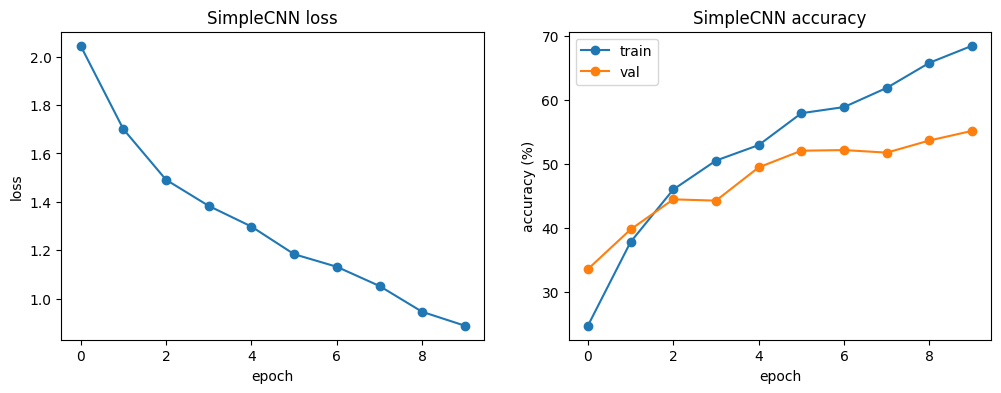

SimpleCNN test accuracy: 53.20%


In [15]:
torch.manual_seed(seed)
cnn_model = SimpleCNN().to(device)
cnn_history = train_model(cnn_model, train_loader, val_loader, epochs=10 if FAST_DEV_RUN else 10, lr=1e-3)
plot_history(cnn_history, 'SimpleCNN')
test_acc = check_accuracy(test_loader, cnn_model)
print(f'SimpleCNN test accuracy: {test_acc:.2f}%')


## 6. MLP vs CNN

MLP는 이미지의 2D topology를 사용하지 않고 flatten합니다. CNN은 local connectivity와 parameter sharing을 사용합니다.

### 비교 실험 안내

MLP와 CNN은 같은 CIFAR-10 이미지를 보지만 inductive bias가 다릅니다.

- MLP는 이미지를 긴 vector로 펼치므로 주변 pixel 관계를 명시적으로 알지 못합니다.
- CNN은 작은 filter를 spatial 위치에 공유해서 적용하므로 edge나 texture 같은 local pattern을 더 자연스럽게 다룹니다.

이번 TODO에서는 day2의 MLP 구현 형식을 떠올리면 됩니다. `Flatten -> Linear -> ReLU -> Linear` 구조입니다.

In [10]:
class CIFARMLP(nn.Module):
    def __init__(self, hidden=512, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3 * 32 * 32, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, num_classes),
        )

    def forward(self, x):
        return self.net(x)


MLP parameters: 1,578,506
CNN parameters: 545,098
Epoch 01: loss=2.0606, train_acc=31.74%, val_acc=38.10%
Epoch 02: loss=1.7231, train_acc=42.50%, val_acc=40.90%
Epoch 03: loss=1.5066, train_acc=48.86%, val_acc=39.90%
Epoch 04: loss=1.2333, train_acc=57.38%, val_acc=42.40%
Epoch 05: loss=1.1806, train_acc=60.14%, val_acc=41.80%
Epoch 06: loss=1.0139, train_acc=66.30%, val_acc=43.40%
Epoch 07: loss=0.9323, train_acc=69.40%, val_acc=42.00%
Epoch 08: loss=0.8002, train_acc=74.58%, val_acc=40.90%
Epoch 09: loss=0.7460, train_acc=75.36%, val_acc=39.40%
Epoch 10: loss=0.6214, train_acc=80.70%, val_acc=39.10%


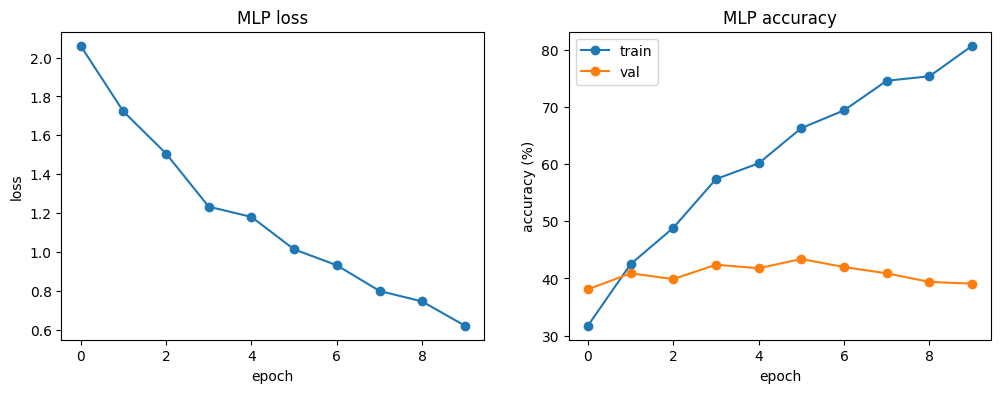

In [11]:
mlp_model = CIFARMLP(hidden=512).to(device)
print(f'MLP parameters: {count_params(mlp_model):,}')
print(f'CNN parameters: {count_params(cnn_model):,}')

torch.manual_seed(seed)
mlp_history = train_model(mlp_model, train_loader, val_loader, epochs=10 if FAST_DEV_RUN else 10, lr=1e-3)
plot_history(mlp_history, 'MLP')


### 결과 해석

parameter 수와 validation accuracy를 함께 보세요. CNN이 항상 parameter 수가 적다고 단정할 수는 없지만, 이미지 문제에서는 같은 parameter budget에서 더 좋은 표현을 배우는 경우가 많습니다.

특히 작은 데이터 subset에서는 결과가 흔들릴 수 있습니다. 그래서 한 번의 숫자보다 여러 epoch 동안의 추세를 보는 것이 더 중요합니다.

## 7. Filter and Feature Map Visualization

### 시각화 안내

CNN은 완전한 black box처럼 보일 수 있지만, 첫 convolution filter와 activation map을 보면 모델이 어떤 local pattern에 반응하는지 감을 잡을 수 있습니다.

첫 번째 시각화는 학습된 filter 자체를 RGB 이미지처럼 보여줍니다. 두 번째 시각화는 특정 입력 이미지가 들어왔을 때 각 filter가 어느 위치에서 강하게 활성화되는지 보여줍니다.

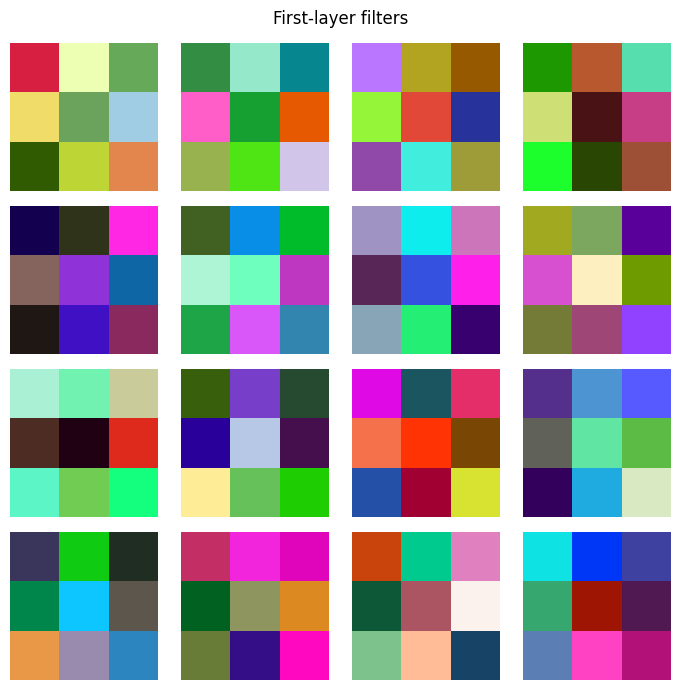

In [16]:
# conv1 filters
conv1 = cnn_model.features[0]
weights = conv1.weight.detach().cpu()

n_show = min(16, weights.size(0))
fig, axes = plt.subplots(4, 4, figsize=(7, 7))
for ax, filt in zip(axes.ravel(), weights[:n_show]):
    f = filt
    f = (f - f.min()) / (f.max() - f.min() + 1e-8)
    ax.imshow(f.permute(1, 2, 0))
    ax.axis('off')
plt.suptitle('First-layer filters')
plt.tight_layout()
plt.show()


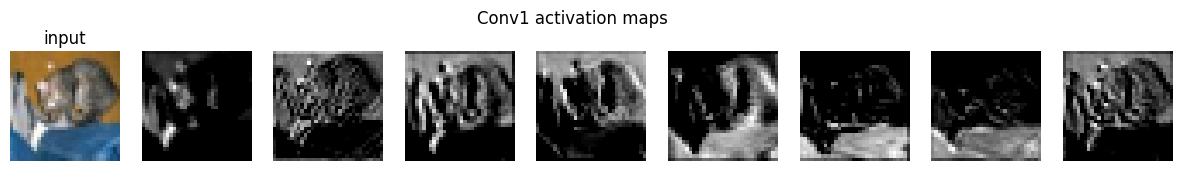

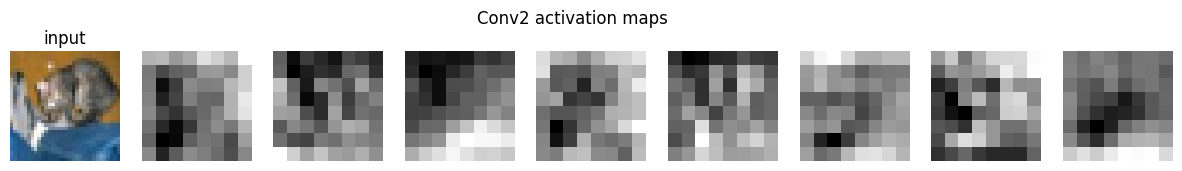

In [17]:
# Feature maps for one image
cnn_model.eval()
sample_img, sample_label = next(iter(test_loader))
sample_img = sample_img[:1].to(device)

with torch.no_grad():
    fmap_conv1 = cnn_model.features[:2](sample_img).cpu()[0]  # after conv1 + ReLU
    fmap_conv2 = cnn_model.features[:5](sample_img).cpu()[0]  # after conv2 + ReLU

fig, axes = plt.subplots(1, 9, figsize=(15, 2))
axes[0].imshow(denormalize(sample_img.cpu()[0]).permute(1, 2, 0))
axes[0].set_title('input')
axes[0].axis('off')

for ax, ch in zip(axes[1:], fmap_conv1[:8]):
    ax.imshow(ch, cmap='gray')
    ax.axis('off')
plt.suptitle('Conv1 activation maps')
plt.show()

fig, axes = plt.subplots(1, 9, figsize=(15, 2))
axes[0].imshow(denormalize(sample_img.cpu()[0]).permute(1, 2, 0))
axes[0].set_title('input')
axes[0].axis('off')

for ax, ch in zip(axes[1:], fmap_conv2[:8]):
    ax.imshow(ch, cmap='gray')
    ax.axis('off')
plt.suptitle('Conv2 activation maps')
plt.show()

### Receptive Field (수용장)

CNN에서 **수용장(Receptive Field)** 은 출력 Feature Map의 한 픽셀이 입력 이미지의 어느 영역에 해당하는지 나타내는 개념입니다.

- **첫 번째 Conv Layer**: 첫 번째 컨볼루션 레이어의 Receptive Field 크기는 필터(kernel)의 크기와 같습니다. 예를 들어, 3x3 필터는 입력 이미지의 3x3 영역을 봅니다.
- **깊은 Conv Layer**: 레이어가 깊어질수록 각 픽셀의 Receptive Field는 더 넓어집니다. 이는 이전 레이어의 출력이 이미 더 넓은 입력 영역의 정보를 압축하고 있기 때문입니다.
- **Pooling Layer**: Max Pooling과 같은 풀링 레이어는 Feature Map의 공간 차원을 줄이면서 Receptive Field를 빠르게 확장하는 효과가 있습니다.

따라서 CNN은 초기 레이어에서 작은 지역적인 특징(예: 엣지, 코너)을 감지하고, 깊은 레이어로 갈수록 더 넓은 영역에서 추상적이고 복합적인 특징을 파악하게 됩니다. 이는 이미지가 계층적인 특징을 포함한다는 인간의 시각 시스템과 유사합니다.

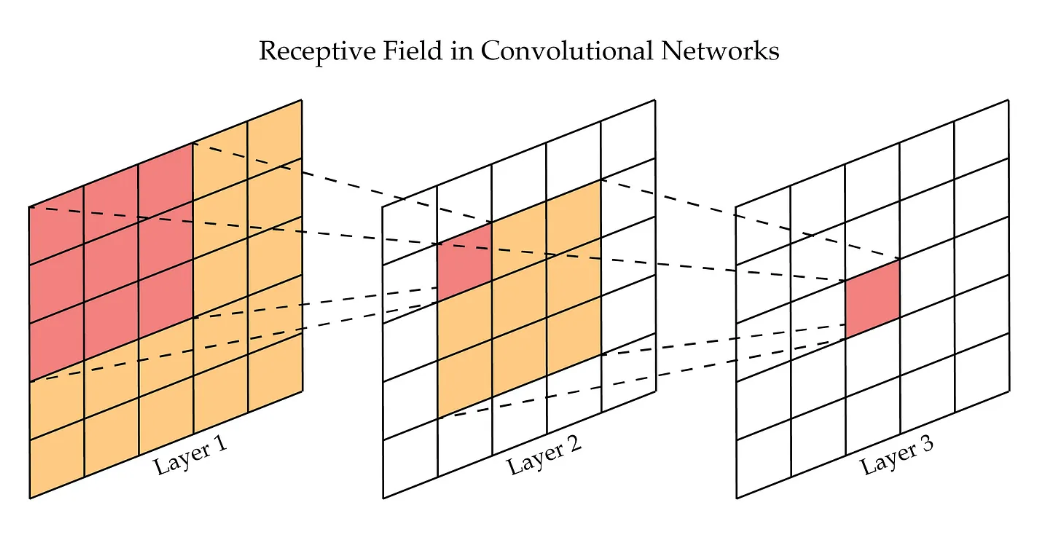


## Summary

이번 실습에서는 강의의 CNN building blocks를 PyTorch 모델로 조립했습니다.

| 관찰 | 의미 |
|---|---|
| Conv2d는 channel 수를 바꾸고 padding으로 spatial size를 제어 | convolution layer의 spatial arrangement |
| MaxPool2d는 spatial size를 줄임 | pooling/subsampling |
| CNN은 MLP보다 이미지 구조를 잘 활용 | local connectivity, parameter sharing |
| filter/feature map 시각화 | filter가 feature detector처럼 동작 |

다음 실습에서는 data augmentation, preprocessing, BatchNorm, Dropout, residual connection을 사용해 CNN 학습을 더 안정화합니다.